In [1]:
import pandas as pd
import yfinance as yf
import numpy as np


In [2]:
tickers = ["NVDA", "AMZN", "SPY", "GLD", "NVO"]
hist = yf.download(tickers, start = "2020-01-01", end = "2025-01-01")
prices = hist["Close"]
returns = prices.pct_change()
returns = returns.dropna()


[*********************100%***********************]  5 of 5 completed


In [3]:
returns.describe()

Ticker,AMZN,GLD,NVDA,NVO,SPY
count,1257.000000,1257.000000,1257.000000,1257.000000,1257.000000
mean,0.000923,0.000462,0.003050,0.001117,0.000618
std,0.022655,0.009780,0.033940,0.019621,0.013227
min,-0.140494,-0.053694,-0.184521,-0.178268,-0.109424
25%,-0.011086,-0.004709,-0.015995,-0.008642,-0.005150
50%,0.000782,0.000618,0.003291,0.000942,0.000900
75%,0.012956,0.005953,0.022306,0.010892,0.007292
max,0.135359,0.048530,0.243696,0.172348,0.090603


In [4]:
annual_return = returns.mean() * 252
annual_vol = returns.std() * np.sqrt(252)

In [5]:
corr_matrix = returns.corr()
corr_matrix

Ticker,AMZN,GLD,NVDA,NVO,SPY
Ticker,,,,,
AMZN,1.000000,0.146091,0.579744,0.211261,0.644515
GLD,0.146091,1.000000,0.128480,0.083687,0.157948
NVDA,0.579744,0.128480,1.000000,0.310121,0.695988
NVO,0.211261,0.083687,0.310121,1.000000,0.381229
SPY,0.644515,0.157948,0.695988,0.381229,1.000000


In [6]:
cov_matrix = returns.cov() * 252

def port_volatility(weights, cov_matrix):
   
    portfolio_var = weights.T @ cov_matrix.values @ weights
    
    return np.sqrt(portfolio_var)

w = np.array([.2,.2,.2,.2,.2])
port_volatility(w,cov_matrix)

np.float64(0.22993946281269328)

In [7]:
from scipy.optimize import minimize
constraints = {'type' : 'eq', 'fun' : lambda w: np.sum(w) - 1}
bounds = tuple((0,1) for _ in range(5))
initial = np.array([.2,.2,.2,.2,.2])
result = minimize(
    port_volatility,
    initial,
    args=(cov_matrix,),
    method = 'SLSQP' , 
    bounds = bounds,
    constraints = constraints
)
optimal_weights = result.x

port_volatility(optimal_weights, cov_matrix) 

np.float64(0.13161795563818843)

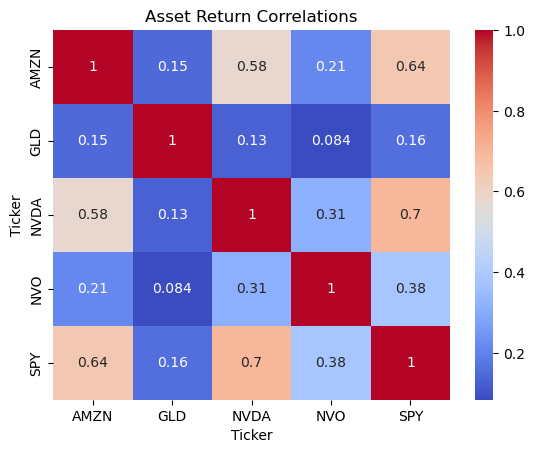

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Asset Return Correlations')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches = 'tight')
plt.show()

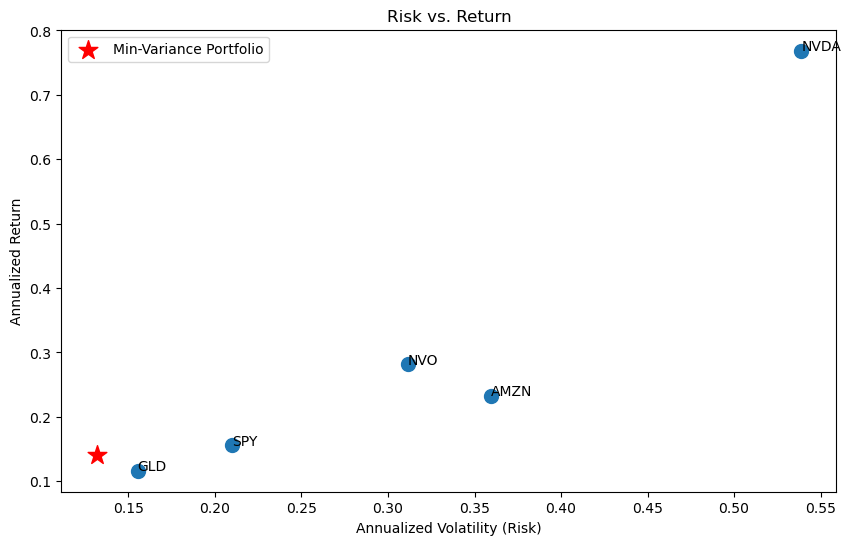

In [9]:
plt.figure(figsize=(10, 6))


plt.scatter(annual_vol, annual_return, s=100)


for ticker in annual_vol.index:
    plt.annotate(ticker, (annual_vol[ticker], annual_return[ticker]))


mvp_vol = port_volatility(optimal_weights, cov_matrix)
mvp_return = np.sum(optimal_weights * annual_return)
plt.scatter(mvp_vol, mvp_return, color='red', s=200, marker='*', label='Min-Variance Portfolio')

plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.title('Risk vs. Return')
plt.legend()
plt.savefig('risk_return_scatter.png', dpi=150, bbox_inches = 'tight')
plt.show()